# Business Scenario

A fintech company provides instant credit limits to customers using a mobile app.
Instead of using complex models, the company wants a similarity-based system that works like:
“Show me customers similar to this new customer, and decide risk accordingly.”

- Challenges:
    - Customers are not easily separable by straight lines
    - Decisions depend on nearness, not formulas
    - Feature scale (income vs age) matters a lot
    - The system must be interactive and explainable

- Load the dataset and explore customer attributes such as:
    - Age
    - Income
    - Loan amount
    - Credit history

     Identify which features should be used to measure customer similarity.

- Prepare the data so that distance-based comparison is meaningful.
- Explain why preprocessing is necessary for this algorithm.
-  Build a classification model that:
    - Assigns a customer to High Risk or Low Risk
    - Makes decisions based on nearest neighbors
-  Train the model using historical customer data.
-  Experiment with different values of K.

- Analyze:
    - What happens when K is very small?
    - What happens when K is very large?

-  Identify the value of K that gives balanced performance.
- Predict risk category for unseen customers.
- Show how the prediction changes when K changes.
-  Evaluate the model using:
    - Accuracy
    - Confusion Matrix
-  Analyze:
    - How many risky customers were correctly identified?
    - How many safe customers were misclassified?
 

In [1]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')

In [2]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [19]:
features = [
    'person_age',
    'person_income',
    'loan_amnt',
    'cb_person_cred_hist_length'
]

X = df[features]

In [23]:
y = df['loan_status']

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,y,
    test_size=0.3,
    random_state=42
)


In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
y_pred = knn.predict(X_test)


In [39]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8004092071611253
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      7613
           1       0.58      0.35      0.44      2162

    accuracy                           0.80      9775
   macro avg       0.71      0.64      0.66      9775
weighted avg       0.78      0.80      0.78      9775



In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[4700  372]
 [ 953  492]]


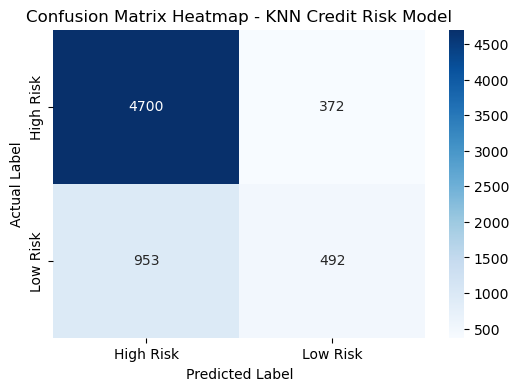

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap = 'Blues',
    xticklabels=["High Risk", "Low Risk"],
    yticklabels=["High Risk", "Low Risk"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap - KNN Credit Risk Model")
plt.show()


1. App Header

- Title: Customer Risk Prediction System (KNN)
Short description:
- “This system predicts customer risk by comparing them with similar customers.”
2. 2️⃣ Sidebar – User Input
    Inputs:
    - Age (slider)
    - Annual Income (number input)
    - Loan Amount (number input)
    - Credit History (Yes / No)
    - K Value (slider: 1–15)

    📌 This slider is crucial — tests understanding of KNN.
3. 3️⃣ Main Prediction Button
    - Button: “Predict Customer Risk”
4. 4️⃣ Prediction Output (Center Screen)
    Display clearly:
    - 🔴 High Risk Customer
    - 🟢 Low Risk Customer

    Color-coded result is mandatory.
5. 5️⃣ Nearest Neighbors Explanation (Tricky &      Powerful)
    Display:
    - Number of neighbors considered
    - Majority class among neighbors
    - Optional: table showing nearest customers
6. 6️⃣ Business Insight Section
    Short explanation:
“This decision is based on similarity with nearby customers in feature space.”